In [1]:
import numpy as np
from scipy import linalg as scplinalg
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import cm

import random

# increase font size for more readable plots
fontsize = 18
plt.rcParams.update({'axes.labelsize': fontsize,
                     'font.size': fontsize,
                     'legend.fontsize': fontsize,
                     'xtick.labelsize': fontsize - 2,
                     'ytick.labelsize': fontsize - 2})
%matplotlib inline

In [2]:
def generate_problem(n, d, s, std=0.06):
    # Generate xs
    # vectors with entries in [0.5, 1] and [-1, -0.5]
    # repectively
    assert s % 2 == 0, "s needs to be divisible by 2"
    xsp = 0.5 * (np.random.rand(s // 2) + 1)
    xsn = - 0.5 * (np.random.rand(s // 2) + 1)
    xsparse = np.hstack([xsp, xsn, np.zeros(d - s)])
    random.shuffle(xsparse)
    # Generate A
    A = np.random.randn(n, d)
    # Generate eps
    y = A @ xsparse + std * np.random.randn(n)
    return xsparse, A, y

In [3]:
n = 1000
d = 500
s = 50
std = 0.06

In [4]:
np.random.seed(2000)
xsparse, A, y = generate_problem(n, d, s, std)

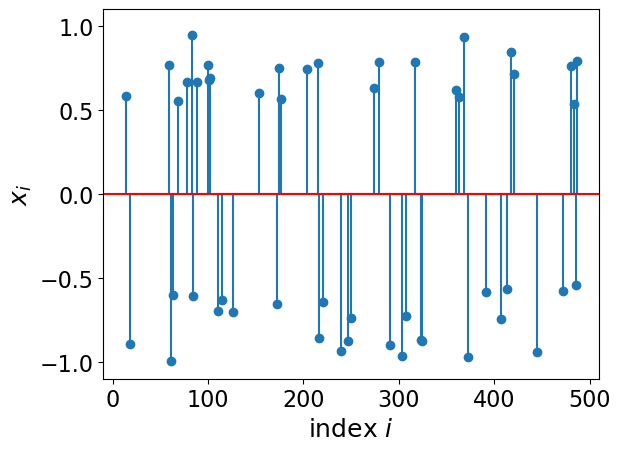

In [5]:
plt.stem(np.arange(len(xsparse))[np.abs(xsparse) > 0], xsparse[np.abs(xsparse) > 0])
plt.axhline(0.0, color="red")
plt.xlim([-10 + 0, d + 10])
plt.ylim([-1.1, 1.1])
plt.xlabel("index $i$")
plt.ylabel("$x_i$")
plt.show()

\begin{equation}
  \min_{x \in \mathbb{R}^d} \Phi(x)\,\qquad \Phi(x) =
  \underbrace{\frac 1 {2n} \|Ax-y\|^2_2}_{:=F(x)} + \lambda \|x\|_1 =
  \frac{1}{n}\sum_{i=1}^n  \phi_i(x) ,
\end{equation}
where
\begin{equation*}
  \phi_i(x)= \underbrace{\frac 1 2  \big( \langle a^i, x_i\rangle  - y_i\big)^2}_{=:f_i(x)}+ \underbrace{\lambda \|x\|_1}_{=:g(x)}
\end{equation*}

In [6]:
def soft_thresholding(x, rho):
    """Soft thresholding of scalar x at level rho."""
    return np.sign(x-rho) * np.maximum(0, np.abs(x) - rho)

def Phi(x, lmbda):
    return np.linalg.norm(A @ x - y)**2 * 0.5 / n + lmbda * np.linalg.norm(x, 1)

grad_F = lambda x: A.T @ (A @ x - y)

def grad_fi(x, i):
    return A[i] * (A[i] @ x - y[i])

def psga(x0, gamma, lmbda, max_iter):

    update = lambda x, i, k: soft_thresholding(x - gamma(k) * grad_fi(x, i), gamma(k) * lmbda)

    x0 = x0
    xs = [x0]
    Phis = [Phi(x0, lmbda)]
    for k in range(max_iter):

        i = np.random.randint(n)
        x_up = update(xs[-1], i, k)

        xs.append(x_up)
        Phis.append(Phi(x_up, lmbda))


    xs = np.vstack([x.flatten() for x in xs])
    Phis = np.vstack(Phis)
    return xs, Phis

def rcpga(x0, gamma, ik, lmbda, max_iter):
    """ik is a function mapping from an integer
    k to an index. gamma is an array of size d (or a function of the index i)."""

    def update(x, i):
        grad = grad_F(x)[i]
        x_up = x.copy()
        x_up[i] = soft_thresholding(x[i] - gamma(i) / n * grad, gamma(i) / n * lmbda)
        return x_up

    ### Run algorithm
    # Keep values in x, start with initial value x0
    x0 = x0
    xs = [x0]
    Phis = [Phi(x0, lmbda)]


    for k in range(max_iter):
        i = ik(k)
        x_up = update(xs[-1], i)

        xs.append(x_up)
        Phis.append(Phi(x_up, lmbda))

    return np.vstack(xs), np.vstack(Phis)

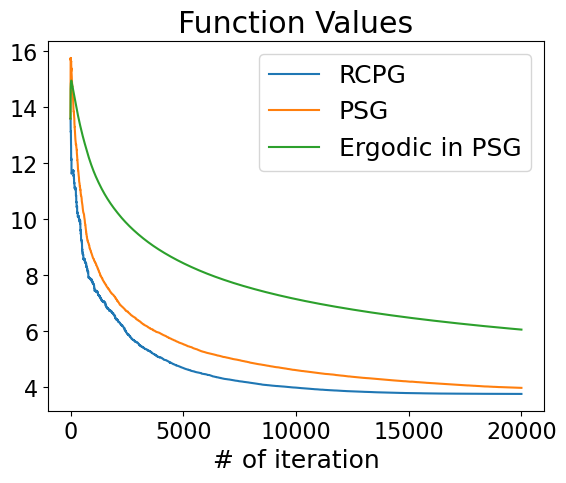

In [7]:
norm_A2 = np.linalg.norm(A, 2)**2
gamma_psga = lambda k: n / (50 * norm_A2 * np.sqrt(k + 1))
vec_norm_A2 = np.array([n / np.linalg.norm(a)**2 for a in A.T])
gamma_rcpga = lambda i: vec_norm_A2[i]
i_randomised = lambda k: np.random.randint(d)
lmbda = 0.1
max_iter = 20000
x0 = np.zeros(d)
x_psga, Phi_psga = psga(x0, gamma_psga, lmbda, max_iter)
x_rcpga, Phi_rcpga = rcpga(x0, gamma_rcpga, i_randomised, lmbda, max_iter)
gamma_psga_list = np.array([gamma_psga(i) for i in range(max_iter + 1)])
cumsum_gamma = np.cumsum(gamma_psga_list)
ergodic_mean = np.cumsum(gamma_psga_list[:, None] * x_psga, axis=0) / cumsum_gamma[:, None]
Phi_erg_mean = np.array([Phi(x, lmbda) for x in ergodic_mean])
plt.figure()
plt.title('Function Values')
plt.plot(Phi_rcpga, label='RCPG')
plt.plot(Phi_psga, label='PSG')
plt.plot(Phi_erg_mean, label='Ergodic in PSG')
plt.xlabel('# of iteration')
plt.legend()
plt.show()



# Appendix
Plot of Proximal operator in Problem 5

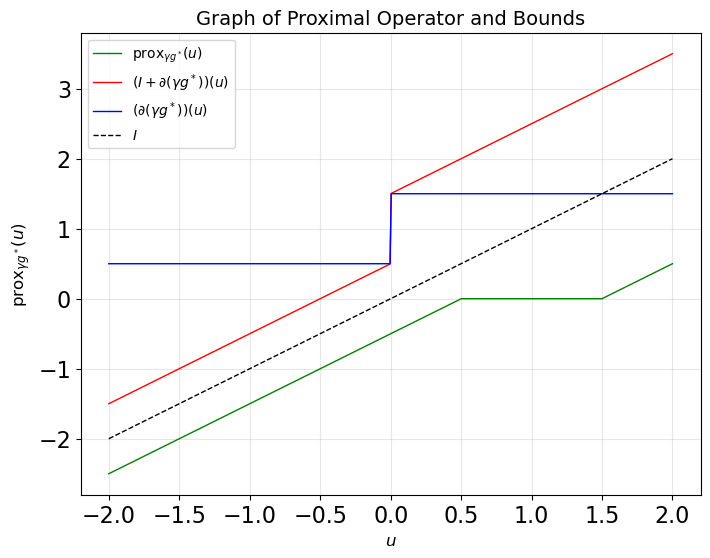

In [20]:
# Parameters
b = 2  # Center of the interval
epsilon = 1  # Width of the interval
gamma = 0.5  # Scaling factor

# Compute thresholds
lower_bound = gamma * (b - epsilon)
upper_bound = gamma * (b + epsilon)

# Generate data for plotting
u = np.linspace(-2, 2, 500)  # u values
subgradient_gamma_g_star = np.zeros_like(u)  # Subgradient of gamma * g^*(u)
identity_subgradient_gamma_g_star = np.zeros_like(u)  # Identity
prox = np.zeros_like(u)

for i, ui in enumerate(u):
    if ui < 0:
        subgradient_gamma_g_star[i] = lower_bound
        identity_subgradient_gamma_g_star[i] = ui + lower_bound
    elif ui > 0:
        subgradient_gamma_g_star[i] = upper_bound
        identity_subgradient_gamma_g_star[i] = ui + upper_bound
    else:
        subgradient_gamma_g_star[i] = np.random.uniform(lower_bound, upper_bound)
        identity_subgradient_gamma_g_star[i] = subgradient_gamma_g_star[i]
    if lower_bound < ui <= upper_bound:
        prox[i] = 0
    elif ui <= lower_bound:
        prox[i] = ui - lower_bound
    else:  # ui > upper_bound
        prox[i] = ui - upper_bound

# Plotting
plt.figure(figsize=(8, 6))

# Plot prox function
plt.plot(u, prox, label=r"$\mathrm{prox}_{\gamma g^*}(u)$", color="green", linewidth=1)
plt.plot(u, identity_subgradient_gamma_g_star, label=r"$(I + \partial (\gamma g^*))(u)$", color="red", linewidth=1)
plt.plot(u, subgradient_gamma_g_star, label=r"$(\partial (\gamma g^*))(u)$", color="blue", linewidth=1)
plt.plot(u, u, label=r"$I$", color="black", linewidth=1, linestyle="--")

# Annotations and labels
plt.title("Graph of Proximal Operator and Bounds", fontsize=14)
plt.xlabel(r"$u$", fontsize=12)
plt.ylabel(r"$\mathrm{prox}_{\gamma g^*}(u)$", fontsize=12)
plt.legend(fontsize=10)
plt.grid(alpha=0.3)

# Show plot
plt.show()